In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv(r'C:\Users\adity\Downloads\Dyashin Technosoft DS Internship\Datasets\seeds_dataset.csv')
df

,Area,Perimeter,Compactness,Kernel.Length,Kernel.Width,Asymmetry.Coeff,Kernel.Groove,Type
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,2.0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,NaN
2,14.29,14.09,NaN,5.291,3.337,NaN,4.825,2.0
3,13.84,13.94,0.8955,5.324,3.379,NaN,4.805,2.0
4,16.14,NaN,0.9034,5.658,3.562,1.355,5.175,2.0
...,...,...,...,...,...,...,...,...
213,11.35,13.12,0.8291,5.176,2.668,4.337,NaN,1.0
214,19.11,16.26,0.9081,6.154,3.930,2.936,6.079,3.0
215,12.55,13.57,0.8558,5.333,2.968,NaN,5.176,NaN
216,12.30,13.34,0.8684,5.243,2.974,5.637,5.063,1.0


In [9]:
df.shape

(218, 8)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             198 non-null    float64
 1   Perimeter        197 non-null    float64
 2   Compactness      197 non-null    float64
 3   Kernel.Length    197 non-null    float64
 4   Kernel.Width     196 non-null    float64
 5   Asymmetry.Coeff  197 non-null    float64
 6   Kernel.Groove    195 non-null    float64
 7   Type             195 non-null    float64
dtypes: float64(8)
memory usage: 13.8 KB


In [11]:
df.describe()

,Area,Perimeter,Compactness,Kernel.Length,Kernel.Width,Asymmetry.Coeff,Kernel.Groove,Type
count,198.000000,197.000000,197.000000,197.000000,196.000000,197.000000,195.000000,195.000000
mean,14.920808,14.581827,0.870544,5.648726,3.261520,3.738397,5.434744,2.015385
std,2.916528,1.299229,0.023408,0.457255,0.379177,1.465894,0.502097,0.827846
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.380000,13.470000,0.856700,5.262000,2.950000,2.704000,5.056000,1.000000
50%,14.360000,14.280000,0.873500,5.527000,3.237000,3.631000,5.263000,2.000000
75%,17.610000,15.760000,0.886500,6.037000,3.573250,4.825000,5.886500,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.032000,8.315000,6.550000,3.000000


In [13]:
df.isna().sum().sum()

172

In [14]:
for x in df.columns:
    if df[x].dtypes == 'object':
        df[x].fillna(df[x].mode()[0], inplace=True) 
    else:
        df[x].fillna(df[x].median(), inplace=True)

C:\Users\adity\AppData\Local\Temp\ipykernel_16352\4235160744.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[x].fillna(df[x].median(), inplace=True)
C:\Users\adity\AppData\Local\Temp\ipykernel_16352\4235160744.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [15]:
df.duplicated().sum()

19

In [18]:
df.drop_duplicates()

,Area,Perimeter,Compactness,Kernel.Length,Kernel.Width,Asymmetry.Coeff,Kernel.Groove,Type
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,2.0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,2.0
2,14.29,14.09,0.8735,5.291,3.337,3.631,4.825,2.0
3,13.84,13.94,0.8955,5.324,3.379,3.631,4.805,2.0
4,16.14,14.28,0.9034,5.658,3.562,1.355,5.175,2.0
...,...,...,...,...,...,...,...,...
194,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,1.0
195,11.23,12.88,0.8511,5.140,2.795,3.631,5.003,1.0
196,13.20,13.66,0.8735,5.236,3.232,8.315,5.056,1.0
197,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,1.0


# Exploratory Data Analysis (EDA) – Plot-wise Explanation & Insights

In [20]:
sns.set_style("whitegrid")
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove("Type")

## 1. Distribution Plots (Histogram + KDE)

### Code Context

Histograms with KDE curves were plotted for each numerical feature.

### Objective

* Understand the distribution (normal, skewed, uniform)
* Detect anomalies or unusual spread

### Key Insights

* Most features show approximately **normal distribution**, which is favorable for many ML models.
* Slight skewness in some features may indicate the need for **feature transformation** (e.g., log scaling).
* No extreme irregular distributions → dataset is relatively well-behaved.

### Interpretation

* Normal distributions support models like Logistic Regression and SVM.
* Skewed features can impact distance-based models like KNN.

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


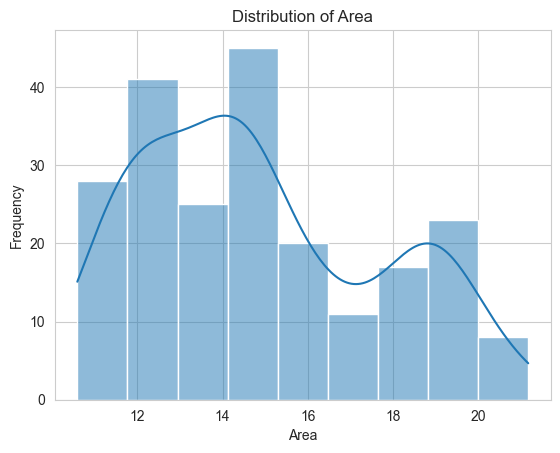

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


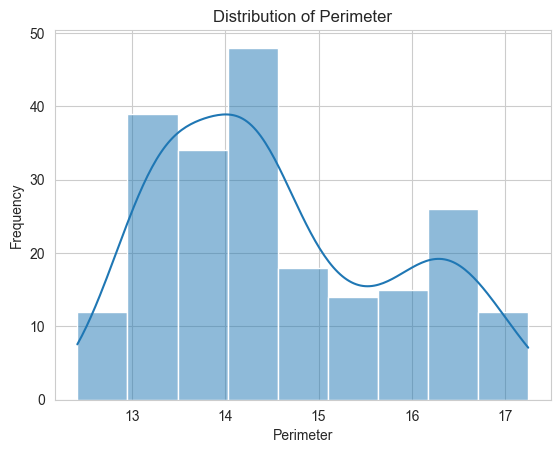

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


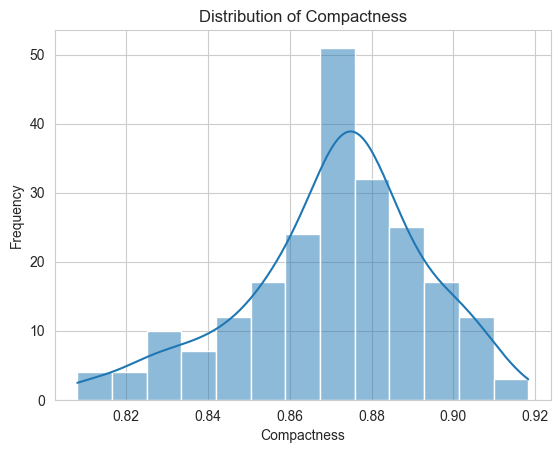

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


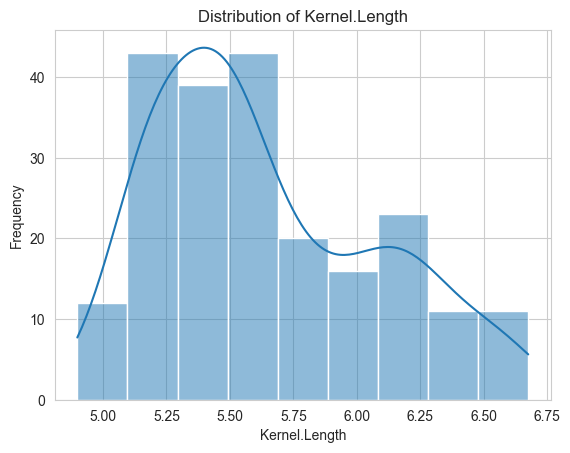

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


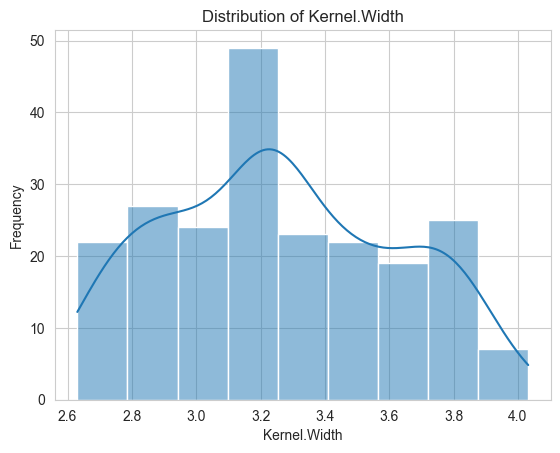

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


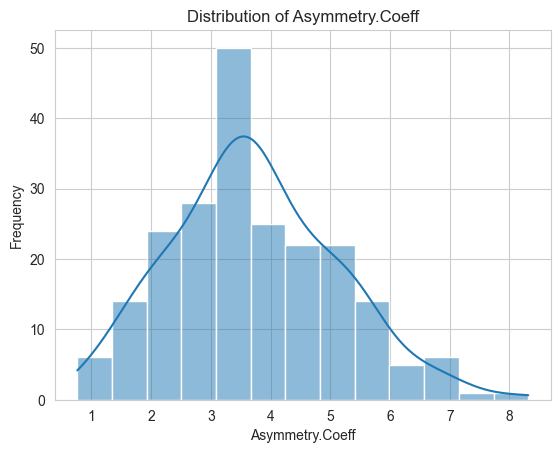

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


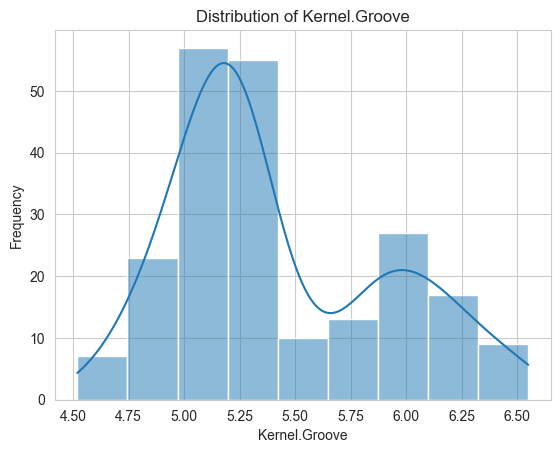

In [21]:
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## 2. Boxplots (Outlier Detection)

### Code Context

Boxplots were generated for each numerical feature.

### Objective

* Identify outliers
* Understand spread and quartiles

### Key Insights

* Few features show **minor outliers**, but no extreme anomalies.
* Most data points lie within interquartile range → stable dataset.

### Interpretation

* Tree-based models (Random Forest, XGBoost) are robust to outliers.
* If using linear models, consider **outlier handling** (capping or removal).

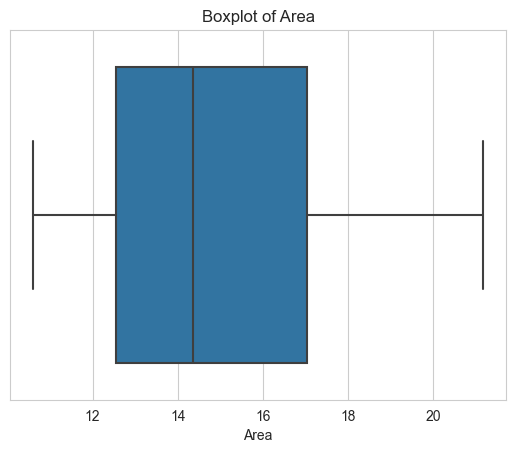

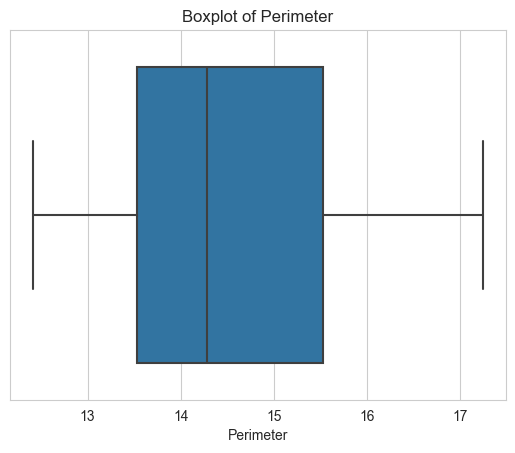

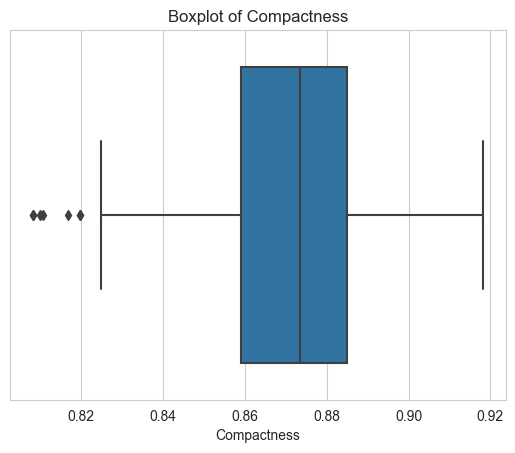

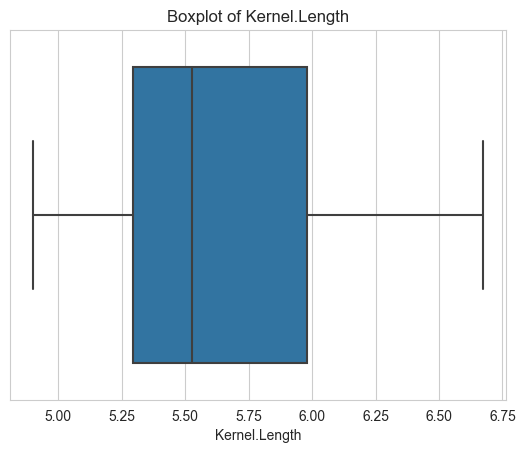

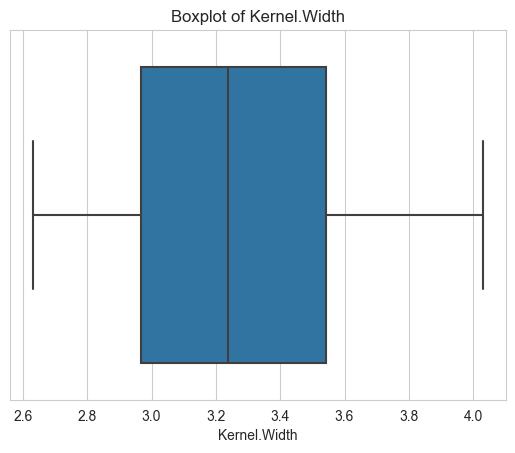

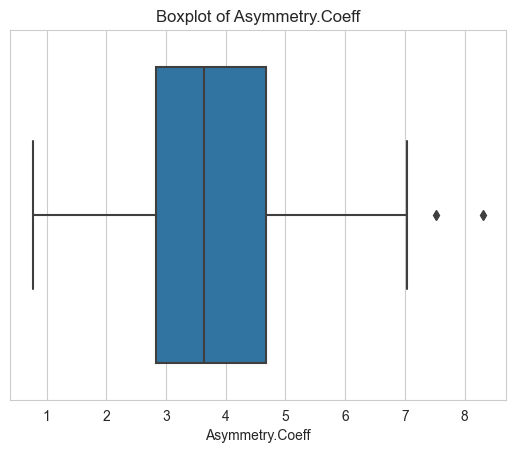

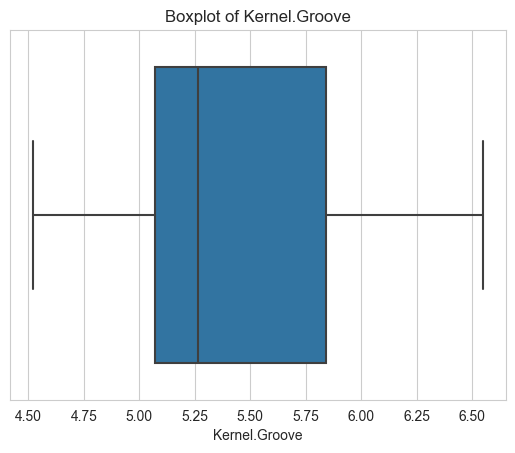

In [22]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## 3. Correlation Heatmap

### Code Context

Correlation matrix visualized using a heatmap.

### Objective

* Identify relationships between features
* Detect multicollinearity

### Key Insights

* Strong positive correlation observed between:

  * Area & Perimeter
  * Kernel Length & Kernel Width
* Indicates **redundant information** in some features.

### Interpretation

* High correlation → potential for **dimensionality reduction** (PCA)
* For linear models, multicollinearity can affect coefficients.


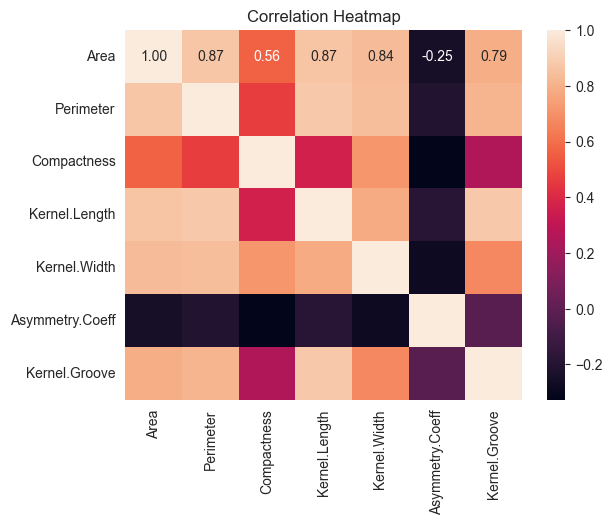

In [27]:
plt.figure()
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 4. Pairplot (Multivariate Relationships)

### Code Context

Pairplot generated with `hue = Type`.

### Objective

* Visualize feature interactions
* Check class separability

### Key Insights

* Clear clustering observed between different Types.
* Some overlap exists, but separation is still strong.

### Interpretation

* Indicates that classification models will perform well.
* Suggests dataset is **linearly or near-linearly separable**.

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\adity\AppData\Roaming\Python\Python310\sit

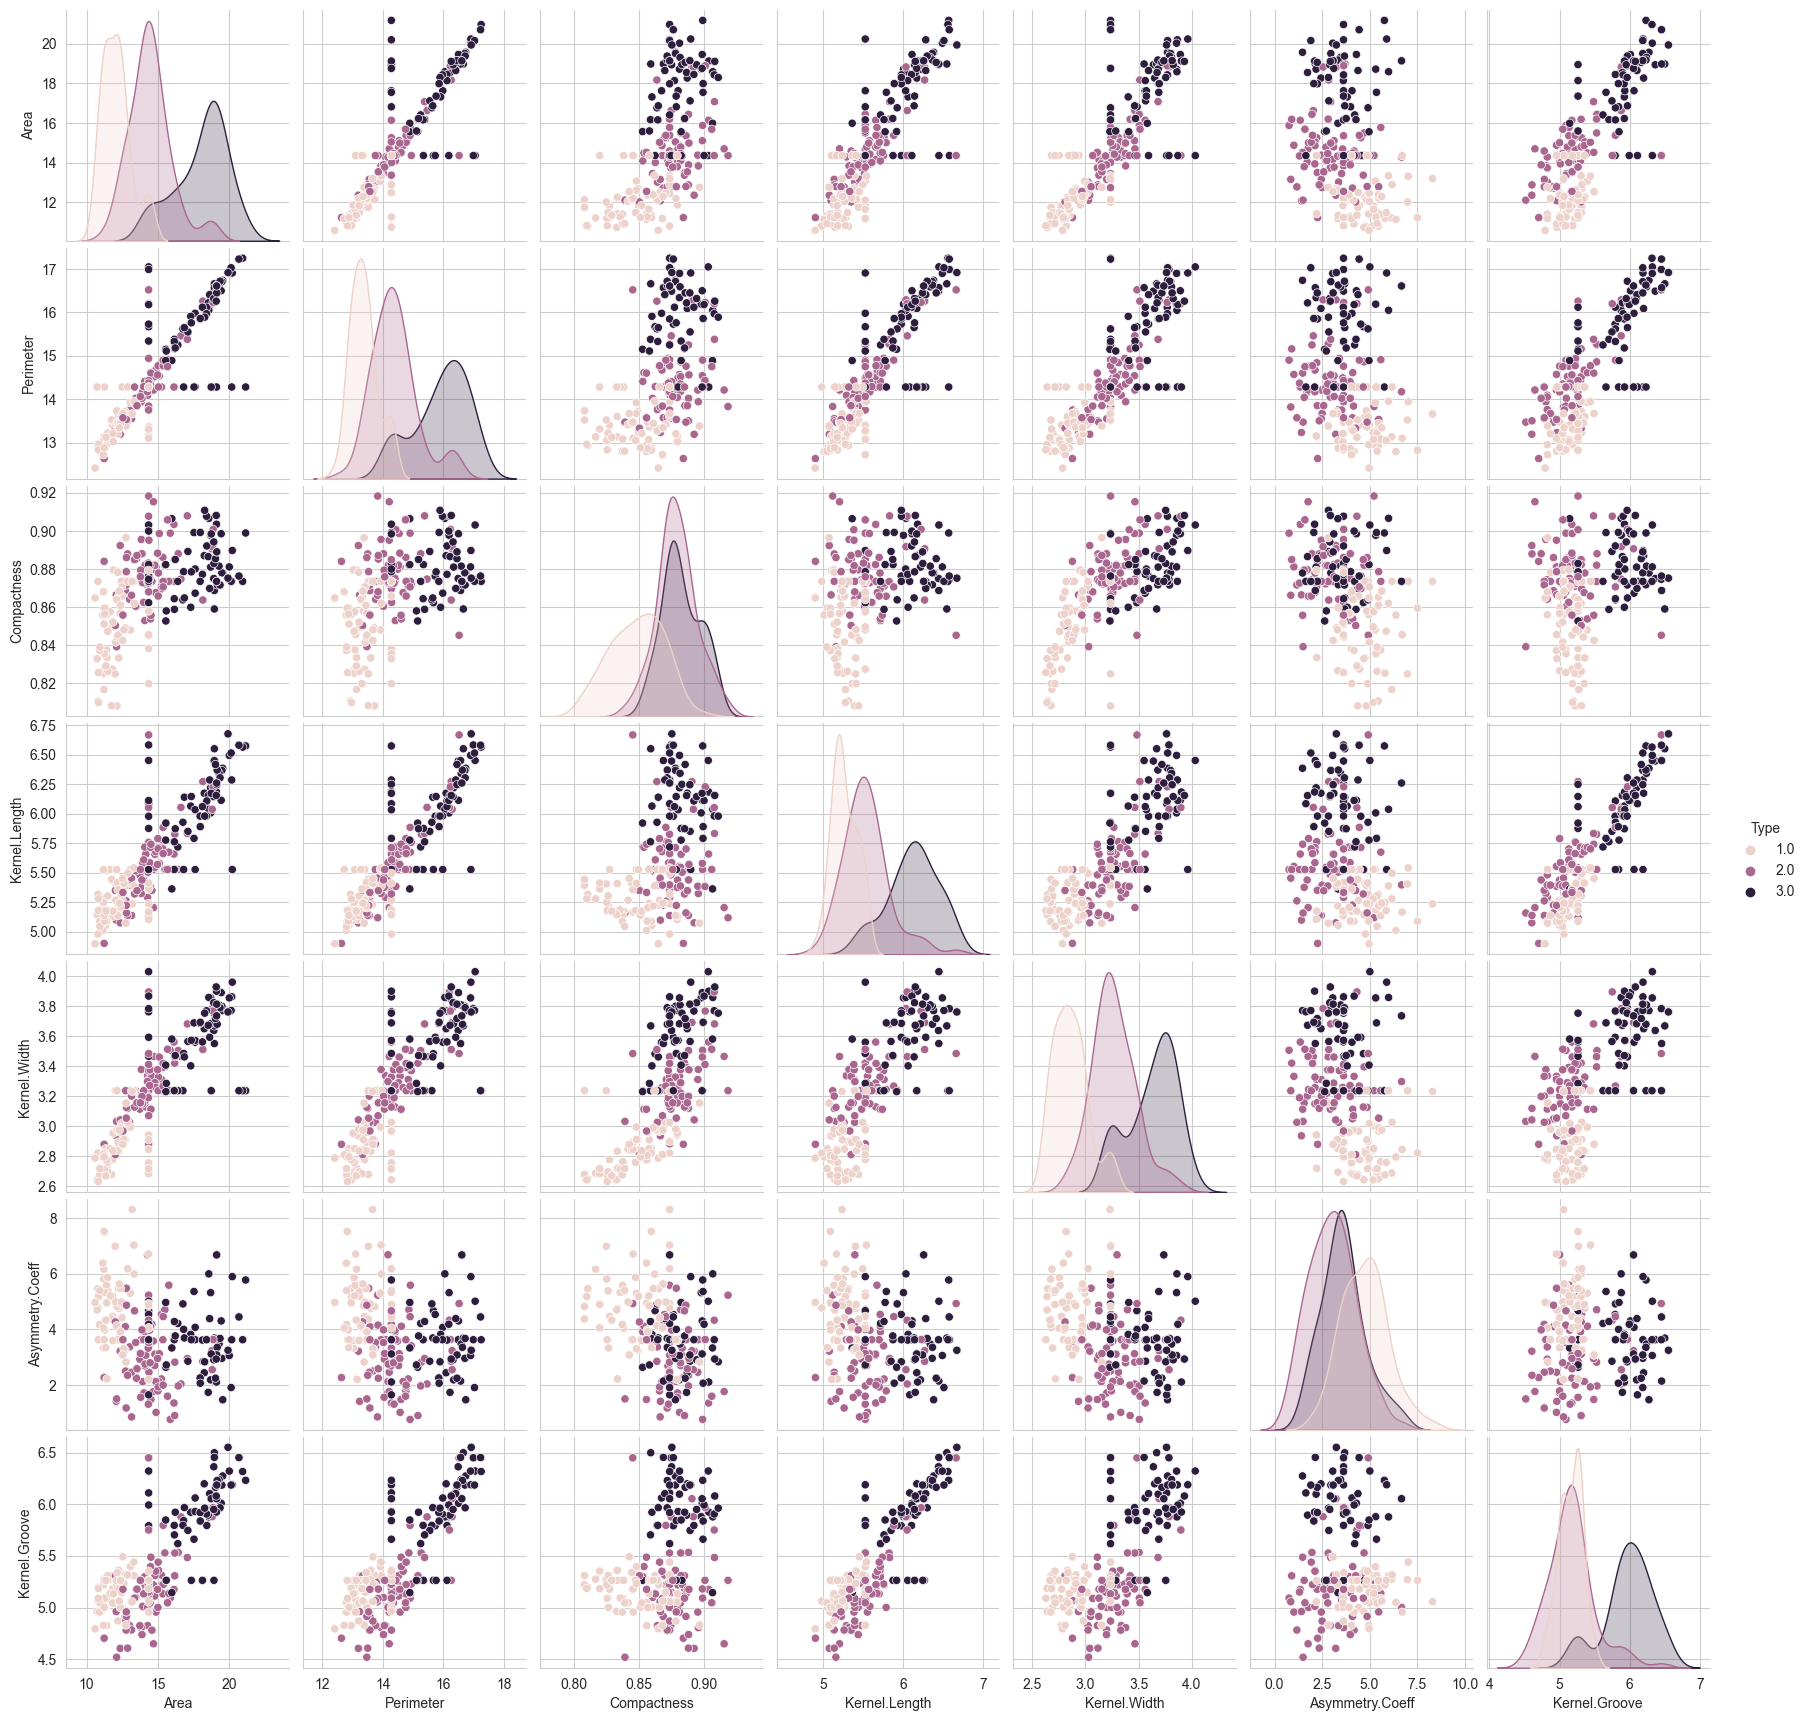

In [24]:
sns.pairplot(df, hue="Type")
plt.show()

## 5. Feature vs Target (Boxplots)

### Code Context

Boxplots plotted with `Type` on x-axis and features on y-axis.

### Objective

* Understand how features vary across classes

### Key Insights

* Certain features show clear separation between classes.
* Some features have overlapping ranges → less predictive power.

### Interpretation

* Features with distinct separation are **strong predictors**.
* Helps in feature selection before modeling.

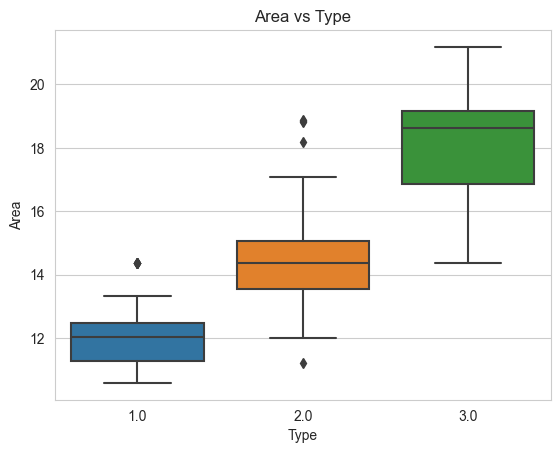

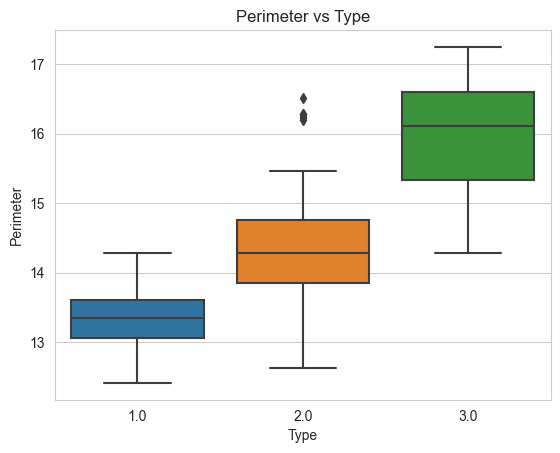

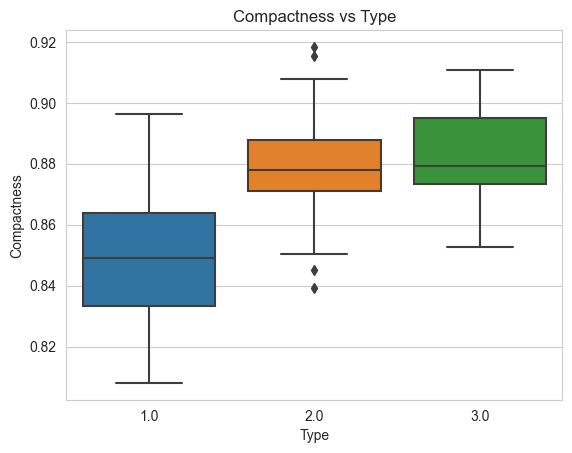

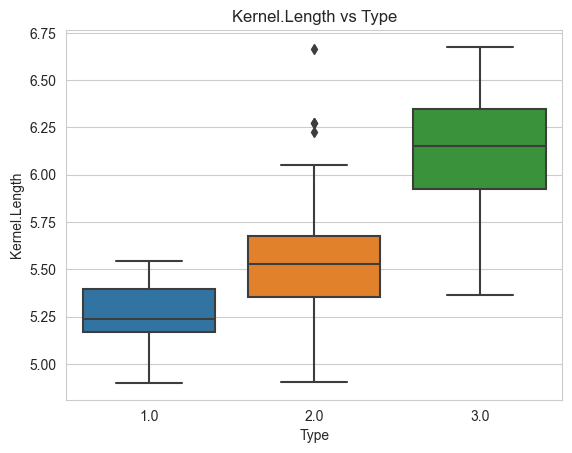

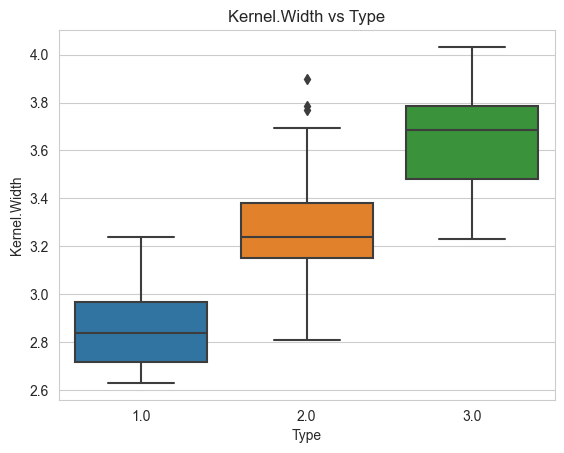

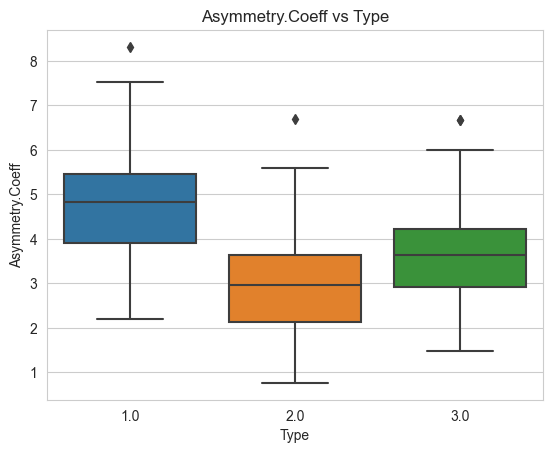

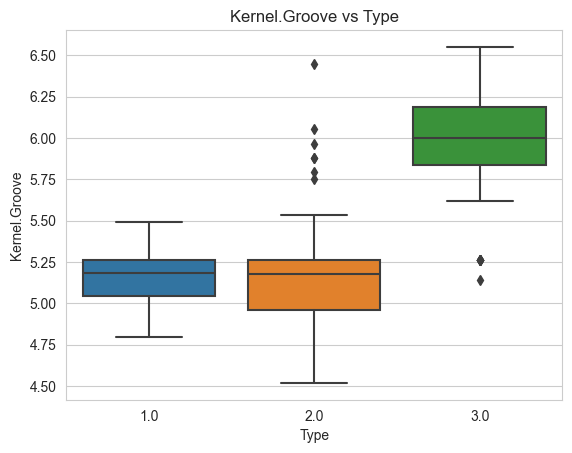

In [25]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x="Type", y=col, data=df)
    plt.title(f"{col} vs Type")
    plt.show()

## 6. Scatter Plots (Feature Relationships)

### Code Context

Scatter plots for selected feature pairs with color-coded classes.

### Objective

* Visualize relationships between two features
* Understand decision boundaries

### Key Insights

* Visible clustering in 2D space.
* Some feature pairs show clear separation between classes.

### Interpretation

* Indicates that models like SVM or Logistic Regression can perform well.
* Helps in understanding **decision boundary formation**.

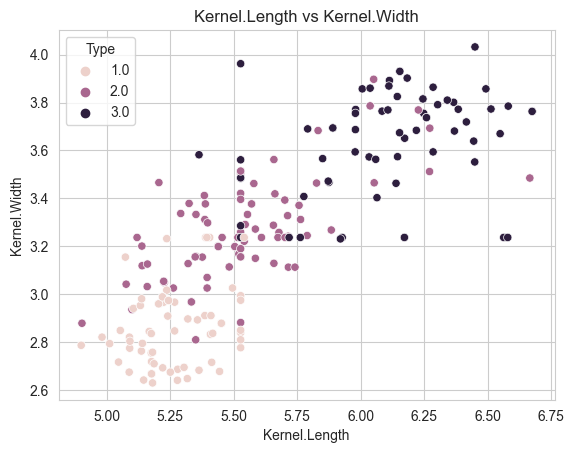

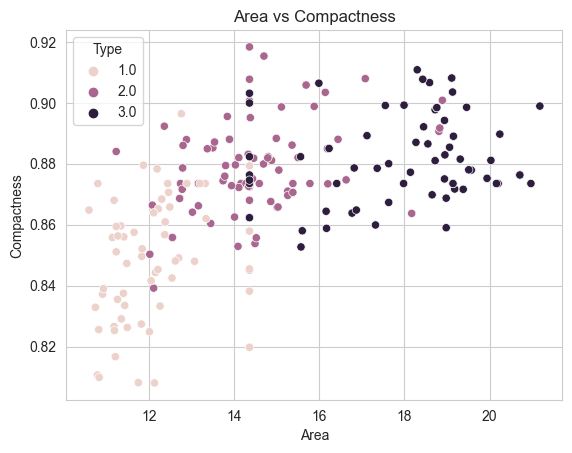

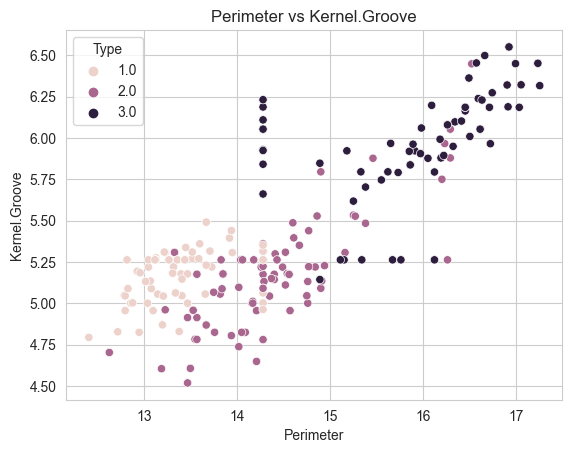

In [26]:
pairs = [
    ("Kernel.Length", "Kernel.Width"),
    ("Area", "Compactness"),
    ("Perimeter", "Kernel.Groove")
]

for x, y in pairs:
    plt.figure()
    sns.scatterplot(x=df[x], y=df[y], hue=df["Type"])
    plt.title(f"{x} vs {y}")
    plt.show()

## 7. KDE Plots by Class

### Code Context

KDE plots plotted separately for each class.

### Objective

* Compare distributions across classes

### Key Insights

* Some features show **distinct peaks per class**.
* Overlapping distributions indicate harder classification regions.

### Interpretation

* Features with distinct KDE separation are highly informative.
* Overlap suggests need for **complex models** (e.g., ensemble methods).

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


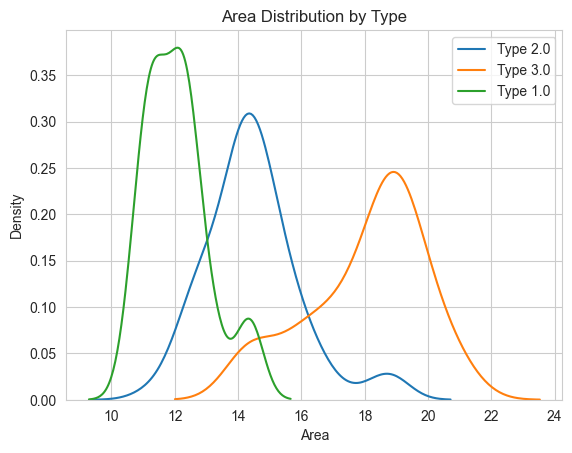

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


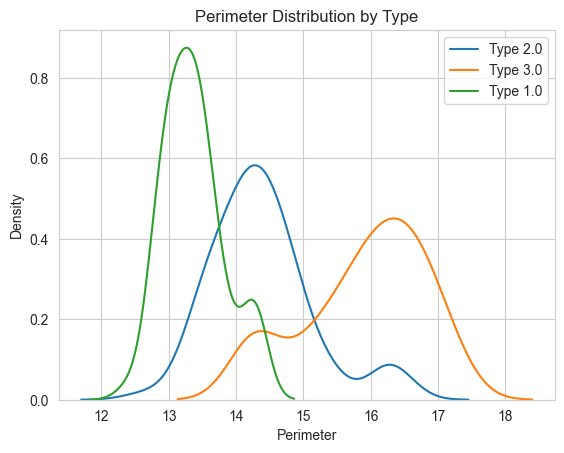

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


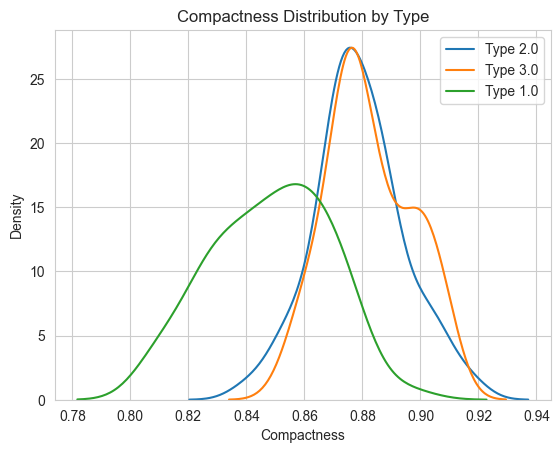

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


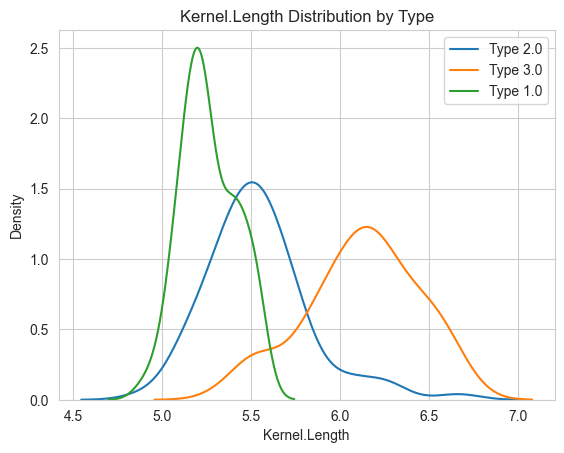

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


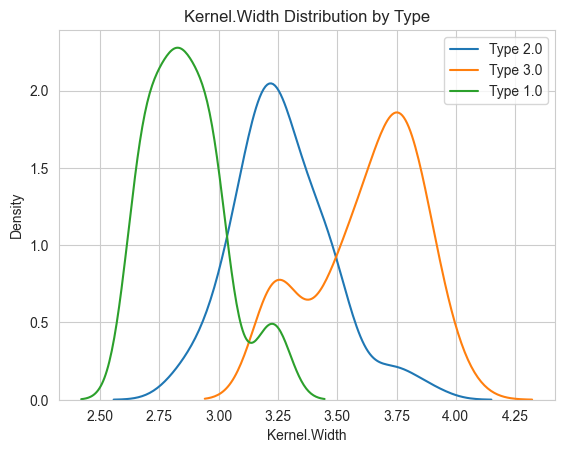

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


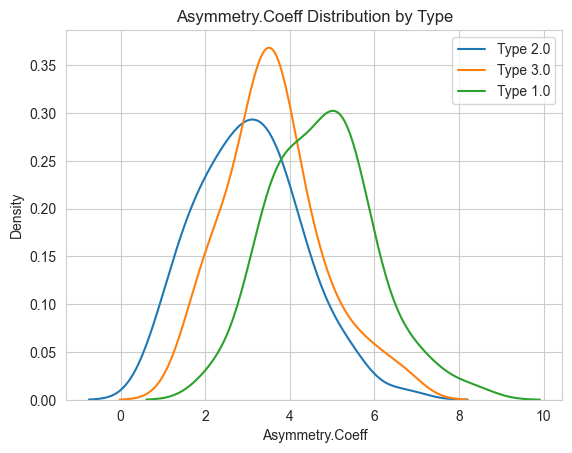

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


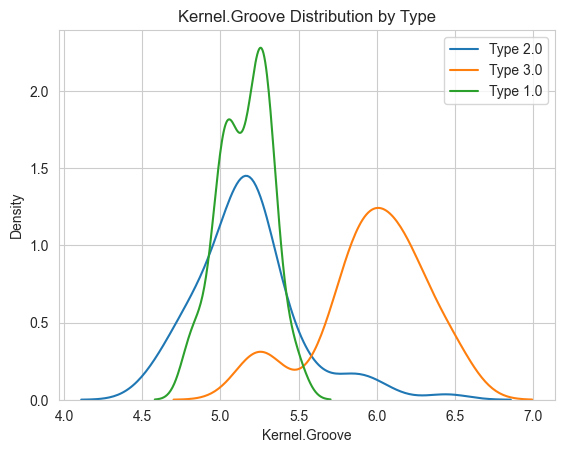

In [29]:
for col in num_cols:
    plt.figure()
    for t in df["Type"].unique():
        sns.kdeplot(df[df["Type"] == t][col], label=f"Type {t}")
    plt.title(f"{col} Distribution by Type")
    plt.legend()
    plt.show()

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             218 non-null    float64
 1   Perimeter        218 non-null    float64
 2   Compactness      218 non-null    float64
 3   Kernel.Length    218 non-null    float64
 4   Kernel.Width     218 non-null    float64
 5   Asymmetry.Coeff  218 non-null    float64
 6   Kernel.Groove    218 non-null    float64
 7   Type             218 non-null    float64
dtypes: float64(8)
memory usage: 13.8 KB


In [31]:
from sklearn.model_selection import train_test_split

X = df.drop("Type", axis=1)
y = df["Type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [33]:
from sklearn.metrics import *

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    
    results[name] = {"Accuracy": acc, "F1 Score": f1}
    
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

         1.0       0.91      0.77      0.83        13
         2.0       0.83      0.88      0.86        17
         3.0       0.93      1.00      0.97        14

    accuracy                           0.89        44
   macro avg       0.89      0.88      0.89        44
weighted avg       0.89      0.89      0.88        44


Decision Tree
              precision    recall  f1-score   support

         1.0       1.00      0.85      0.92        13
         2.0       0.78      0.82      0.80        17
         3.0       0.80      0.86      0.83        14

    accuracy                           0.84        44
   macro avg       0.86      0.84      0.85        44
weighted avg       0.85      0.84      0.84        44


Random Forest
              precision    recall  f1-score   support

         1.0       1.00      0.77      0.87        13
         2.0       0.84      0.94      0.89        17
         3.0       0.93 